In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [2]:
df = pd.read_csv('청년정책목록_전체.csv', encoding='utf-8')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plcyNo             3458 non-null   object 
 1   bscPlanCycl        3458 non-null   int64  
 2   bscPlanPlcyWayNo   3458 non-null   int64  
 3   bscPlanFcsAsmtNo   3458 non-null   int64  
 4   bscPlanAsmtNo      3458 non-null   int64  
 5   pvsnInstGroupCd    3458 non-null   int64  
 6   plcyPvsnMthdCd     623 non-null    float64
 7   plcyAprvSttsCd     3458 non-null   int64  
 8   plcyNm             3458 non-null   object 
 9   plcyKywdNm         956 non-null    object 
 10  plcyExplnCn        3458 non-null   object 
 11  lclsfNm            3421 non-null   object 
 12  mclsfNm            3421 non-null   object 
 13  plcySprtCn         3458 non-null   object 
 14  sprvsnInstCd       2464 non-null   object 
 15  sprvsnInstCdNm     3440 non-null   object 
 16  sprvsnInstPicNm    766 n

In [4]:
# 정책번호
# 필요없는 컬럼
df['plcyNo']

# plcyNo 중복 데이터 확인
print(f"전체 데이터 수: {len(df)}")
print(f"고유한 plcyNo 수: {df['plcyNo'].nunique()}")

# 중복된 plcyNo 있는지 확인
duplicates = df['plcyNo'].duplicated().sum()
print(f"중복된 plcyNo 개수: {duplicates}")

# 중복된 plcyNo가 있다면 어떤 번호가 중복되었는지 확인
if duplicates > 0:
    duplicate_values = df[df['plcyNo'].duplicated(keep=False)].sort_values('plcyNo')
    print("중복된 plcyNo 값:")
    display(duplicate_values[['plcyNo']])

전체 데이터 수: 3458
고유한 plcyNo 수: 3458
중복된 plcyNo 개수: 0


# 기본계획

In [5]:
# 기본계획차수, 기본계획정책방향번호, 기본계획중점과제번호, 기본계획과제번호
df[['bscPlanCycl', 'bscPlanPlcyWayNo', 'bscPlanFcsAsmtNo', 'bscPlanAsmtNo']]

,bscPlanCycl,bscPlanPlcyWayNo,bscPlanFcsAsmtNo,bscPlanAsmtNo
0,1,3,10,23
1,1,4,14,35
2,1,4,15,39
3,1,4,13,32
4,1,4,13,32
...,...,...,...,...
3453,1,4,15,40
3454,1,2,6,13
3455,1,1,2,4
3456,1,3,10,23


In [6]:
# 기본계획차수
# 필요없는 컬럼
df['bscPlanCycl'].value_counts()

bscPlanCycl
1    3458
Name: count, dtype: int64

<Axes: xlabel='bscPlanPlcyWayNo', ylabel='count'>

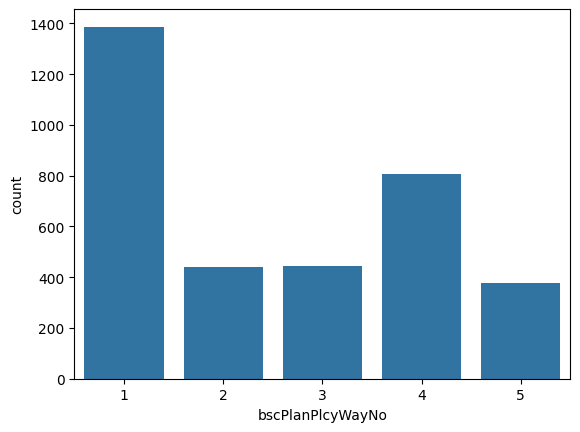

In [18]:
# 기본계획정책방향번호
sns.countplot(data=df, x='bscPlanPlcyWayNo')

<Axes: xlabel='bscPlanFcsAsmtNo', ylabel='count'>

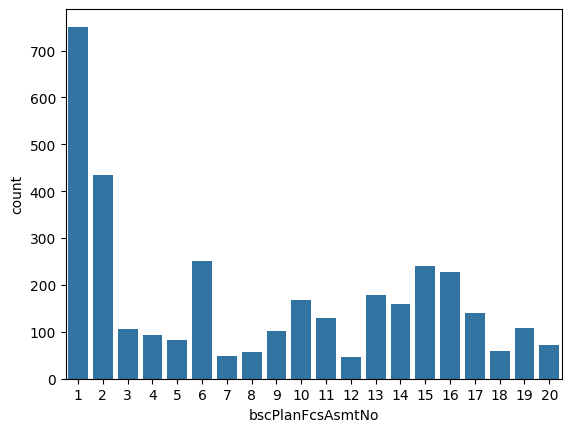

In [11]:
# 기본계획중점과제번호
sns.countplot(data=df, x='bscPlanFcsAsmtNo')

<Axes: xlabel='bscPlanAsmtNo', ylabel='count'>

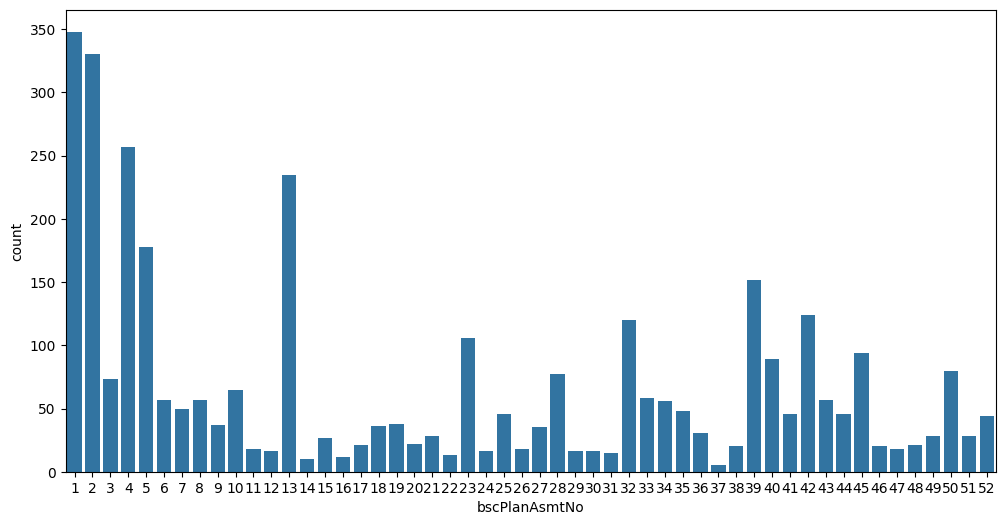

In [14]:
# 기본계획과제번호
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='bscPlanAsmtNo')

In [ ]:
# 기본계획 데이터들이 필요한가?

# 제공기관그룹

In [36]:
# 제공기관그룹코드
df['pvsnInstGroupCd'].value_counts()
# 지자체, 정부?

pvsnInstGroupCd
54002    3038
54001     420
Name: count, dtype: int64

# 정책

In [39]:
# 정책제공방법코드, 정책승인상태코드, 정책명, 정책키워드명, 정책설명내용, 정책지원내용, 정책신청방법내용
df[['plcyPvsnMthdCd', 'plcyAprvSttsCd', 'plcyNm', 'plcyKywdNm', 'plcyExplnCn', 'plcySprtCn', 'plcyAplyMthdCn']].head(5)


,plcyPvsnMthdCd,plcyAprvSttsCd,plcyNm,plcyKywdNm,plcyExplnCn,plcySprtCn,plcyAplyMthdCn
0,42013.0,44002,주거안정장학금,"보조금,교육지원",원거리 대학 진학으로 인해 주거 관련 비용 부담이 큰 저소득 대학생을 대상으로 주거...,"□ 지원금액: 월 최대 20만 원\n※ 단, 방학 중(7~8월, 1~2월)에는 지원...",□ 2학기 신청일정: 2025. 5. 23.(금) 9시 ~ 6. 23.(월) 18시...
1,42010.0,44002,부산 청년돌봄이음,바우처,고립·은둔 청년 및 가족돌봄 청(소)년 지원,"1. 청년 돌봄이음 시범사업(제공기관 : 종합사회복지관) : 초기상담, 성장 계획 ...",부산사회서비스원 홈페이지온라인 신청\n○ 고립은둔 청년 지원 신청 : https:/...
2,42005.0,44002,서울 청년 마음건강 지원사업,맞춤형상담서비스,우울·불안 등 정서적 어려움을 겪는 청년의 마음건강 회복,ㅇ (사업 내용) 2단계 선별검사로 과학적 진단을 통한 맞춤형 상담 지원\n ...,"총 4차(1월, 4월, 6월, 9월)에 걸쳐 참여자를 모집하며, 연도내 중복참여는 ..."
3,42005.0,44002,희망두배 청년통장,금리혜택,"학자금 대출, 주거비, 비정규직 취업 등으로 어려움을 겪고 있는 청년의 자립지원을 ...",□ 본인저축액 : 월 15만원\n□ 매칭지원액 : 본인저축액과 동일한 금액 매월 적...,□ 신청기간 : 2025. 6. 9.(월) ~ 6. 20.(금) 18:00 ※ 신청...
4,42002.0,44002,서울 영테크,맞춤형상담서비스,청년 금융교육 및 재무상담을 통한 경제적 자립 지원,"무료 재무상담(대면, 비대면) 및 금융교육, 커뮤니티 운영\nㅇ (재무상담) 재무진...",NaN


In [17]:
# 정책제공방법코드
df['plcyPvsnMthdCd'].value_counts()

plcyPvsnMthdCd
42006.0    165
42013.0    163
42002.0    141
42004.0     46
42001.0     33
42010.0     31
42005.0     24
42011.0      9
42003.0      5
42007.0      4
42012.0      1
42008.0      1
Name: count, dtype: int64

In [ ]:
# 정책승인상태코드
# 필요없는 컬럼
df['plcyAprvSttsCd'].value_counts()

plcyAprvSttsCd
44002    3458
Name: count, dtype: int64

In [20]:
# 정책키워드명
# ,로 구분된 키워드 분리작업 필요


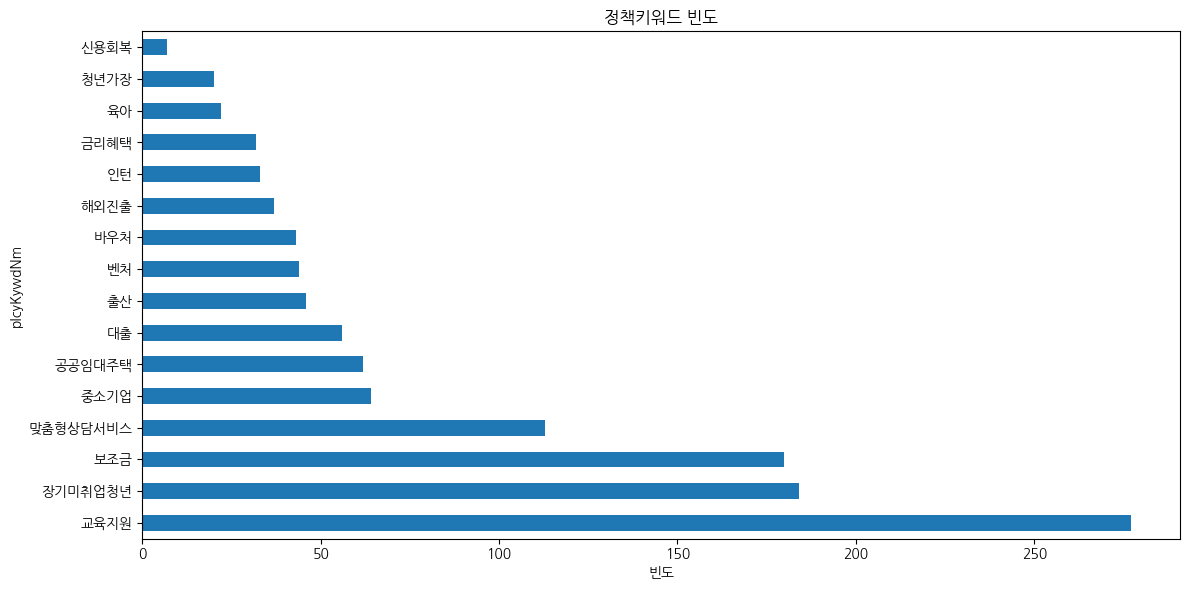

In [25]:
# 쉼표로 분리하여 키워드 카운트
all_keywords = df['plcyKywdNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 키워드 총 16개
plt.figure(figsize=(12, 6))
keyword_counts.plot(kind='barh')
plt.title('정책키워드 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

# 분류

In [44]:
# 정책대분류명, 정책중분류명
df[['lclsfNm', 'mclsfNm']]

,lclsfNm,mclsfNm
0,교육,교육비지원
1,복지문화,취약계층 및 금융지원
2,복지문화,건강
3,복지문화,취약계층 및 금융지원
4,복지문화,취약계층 및 금융지원
...,...,...
3453,"복지문화,복지문화","취약계층 및 금융지원,건강"
3454,"주거,주거","주택 및 거주지,전월세 및 주거급여 지원"
3455,"일자리,일자리","취업,창업"
3456,"일자리,교육,복지문화","취업,미래역량강화,취약계층 및 금융지원"


In [26]:
# 정책대분류명, 중분류명 ,로 구분된 키워드 분리작업 필요

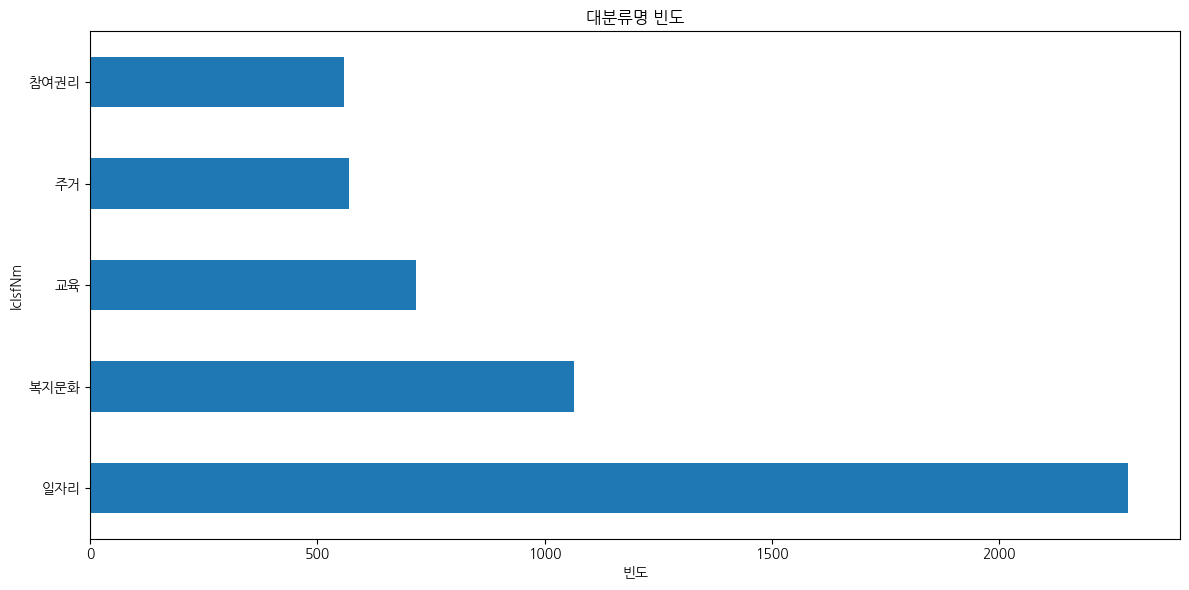

In [28]:
# 쉼표로 분리하여 대분ㄹ명 카운트
all_keywords = df['lclsfNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 시각화
plt.figure(figsize=(12, 6))
keyword_counts.head(15).plot(kind='barh')
plt.title('대분류명 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

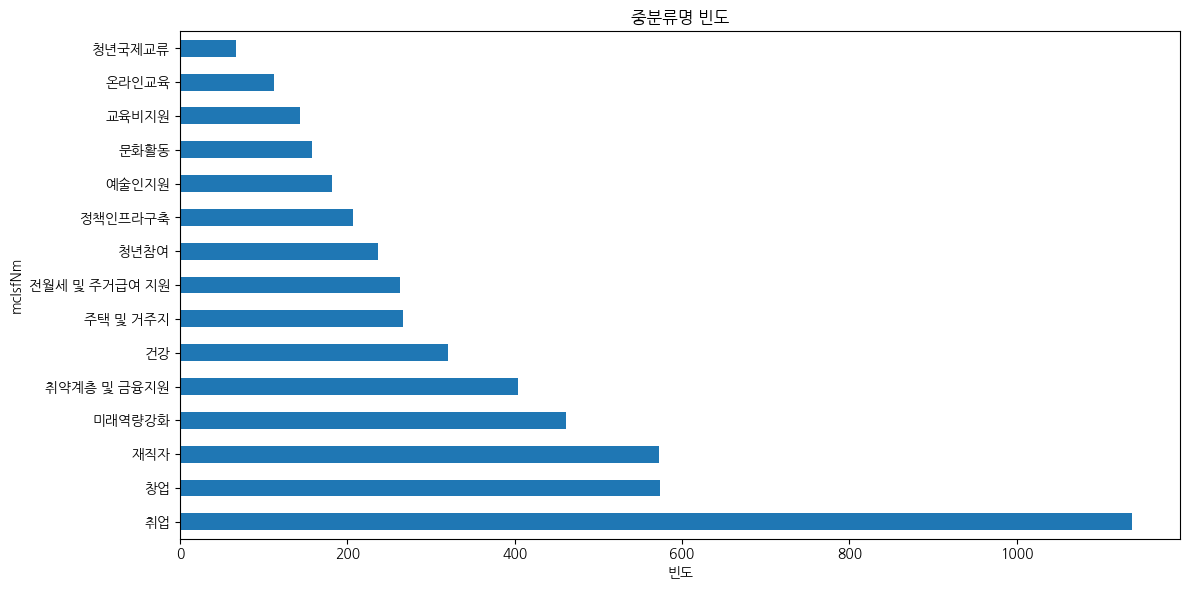

In [29]:
# 쉼표로 분리하여 중분류명 카운트
all_keywords = df['mclsfNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 상위 15개 시각화
plt.figure(figsize=(12, 6))
keyword_counts.head(15).plot(kind='barh')
plt.title('중분류명 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

In [ ]:
# 정책키워드와 중분류명의 데이터가 비슷한 성격을 가짐

# 주관기관

In [43]:
# 주관기관코드, 주관기관코드명, 주관기관담당자명
# 주관기관코드, 주관기관담당자명 컬럼 필요 없음
df[['sprvsnInstCd', 'sprvsnInstCdNm', 'sprvsnInstPicNm']]

,sprvsnInstCd,sprvsnInstCdNm,sprvsnInstPicNm
0,1342000,교육부,NaN
1,6260000,부산광역시,NaN
2,6114551,청년사업담당관,김진희
3,6114679,돌봄고독정책관,돌봄복지과 윤동민
4,6114551,청년사업담당관,이지원
...,...,...,...
3453,1383000,여성가족부,NaN
3454,1613039,국토교통부 주택기금과,NaN
3455,1721000,과학기술정보통신부,NaN
3456,5080341,구미시청 인구청년과,NaN


In [49]:
# 주관기관코드명 값 확인
# 고유한 주관기관코드명의 개수 확인
print(f"주관기관코드명(sprvsnInstCdNm)의 고유 값 개수: {df['sprvsnInstCdNm'].nunique()}")

# 각 값의 출현 빈도 확인
sprvsnInstCdNm_counts = df['sprvsnInstCdNm'].value_counts()
print(f"상위 20개 주관기관코드명:")
display(sprvsnInstCdNm_counts.head(20))

# 하나의 정책만 가진 기관 수 확인
single_policy_institutions = sprvsnInstCdNm_counts[sprvsnInstCdNm_counts == 1].count()
print(f"하나의 정책만 가진 기관 수: {single_policy_institutions}")

주관기관코드명(sprvsnInstCdNm)의 고유 값 개수: 1720
상위 20개 주관기관코드명:


sprvsnInstCdNm
고용노동부            83
보건복지부            42
충청북도             37
전북특별자치도          32
-                29
국토교통부            28
전라남도             25
경상북도             23
교육부              23
경기도              23
중소벤처기업부          23
서울특별시            22
전북특별자치도 익산시      20
인천광역시 청년정책담당관    19
서산시              18
전북청년허브센터         17
부산진구             17
청년정책과            17
경상남도             17
문화체육관광부          16
Name: count, dtype: int64

하나의 정책만 가진 기관 수: 1252


# 운영기관

In [33]:
# 운영기관코드, 운영기관코드명, 운영기관담당자명
# 담당자명은 개인정보이므로 컬럼 제거 필요
df[['operInstCd', 'operInstCdNm', 'operInstPicNm']]

,operInstCd,operInstCdNm,operInstPicNm
0,B552529,한국장학재단,NaN
1,,NaN,NaN
2,,NaN,NaN
3,,NaN,NaN
4,,NaN,NaN
...,...,...,...
3453,B550928,"지역별 학교밖청소년지원센터, 국민건강보험공단 등",NaN
3454,B553511,주택도시보증공사,NaN
3455,B553571,ICT폴리텍대학,NaN
3456,5080000,경상북도 구미시,NaN


In [36]:
df['operInstCd'].isnull().sum()  # 운영기관코드 결측치 확인

np.int64(1369)

In [39]:
# 운영기관코드명 값 확인
# 고유한 운영기관코드명의 개수 확인
print(f"운영기관코드명(operInstCdNm)의 고유 값 개수: {df['operInstCdNm'].nunique()}")
print(f"운영기관코드명 결측치 개수: {df['operInstCdNm'].isnull().sum()}")

# 각 값의 출현 빈도 확인
operInstCdNm_counts = df['operInstCdNm'].value_counts()
print(f"\n상위 20개 운영기관코드명:")
display(operInstCdNm_counts.head(20))

# 하나의 정책만 가진 운영기관 수 확인
single_policy_institutions = operInstCdNm_counts[operInstCdNm_counts == 1].count()
print(f"\n하나의 정책만 가진 운영기관 수: {single_policy_institutions}")
print(f"전체 운영기관 중 하나의 정책만 가진 기관 비율: {single_policy_institutions/len(operInstCdNm_counts)*100:.1f}%")

운영기관코드명(operInstCdNm)의 고유 값 개수: 1493
운영기관코드명 결측치 개수: 607

상위 20개 운영기관코드명:


operInstCdNm
주관기관과 동일           477
-                   41
주관기관 동일             36
한국장학재단              26
전북특별자치도 익산시         19
전북청년허브센터            17
경기도 화성시             16
부산경제진흥원             15
부산진구                15
서비스 제공기관            11
한국산업인력공단            10
기획예산실               10
경기도 하남시             10
경기도 평택시             10
경기도 안성시             10
김제청년공간이다             9
경기도 성남시              9
군산시 청년뜰              9
인천광역시 동구 일자리경제과      9
제천시                  8
Name: count, dtype: int64


하나의 정책만 가진 운영기관 수: 1180
전체 운영기관 중 하나의 정책만 가진 기관 비율: 79.0%


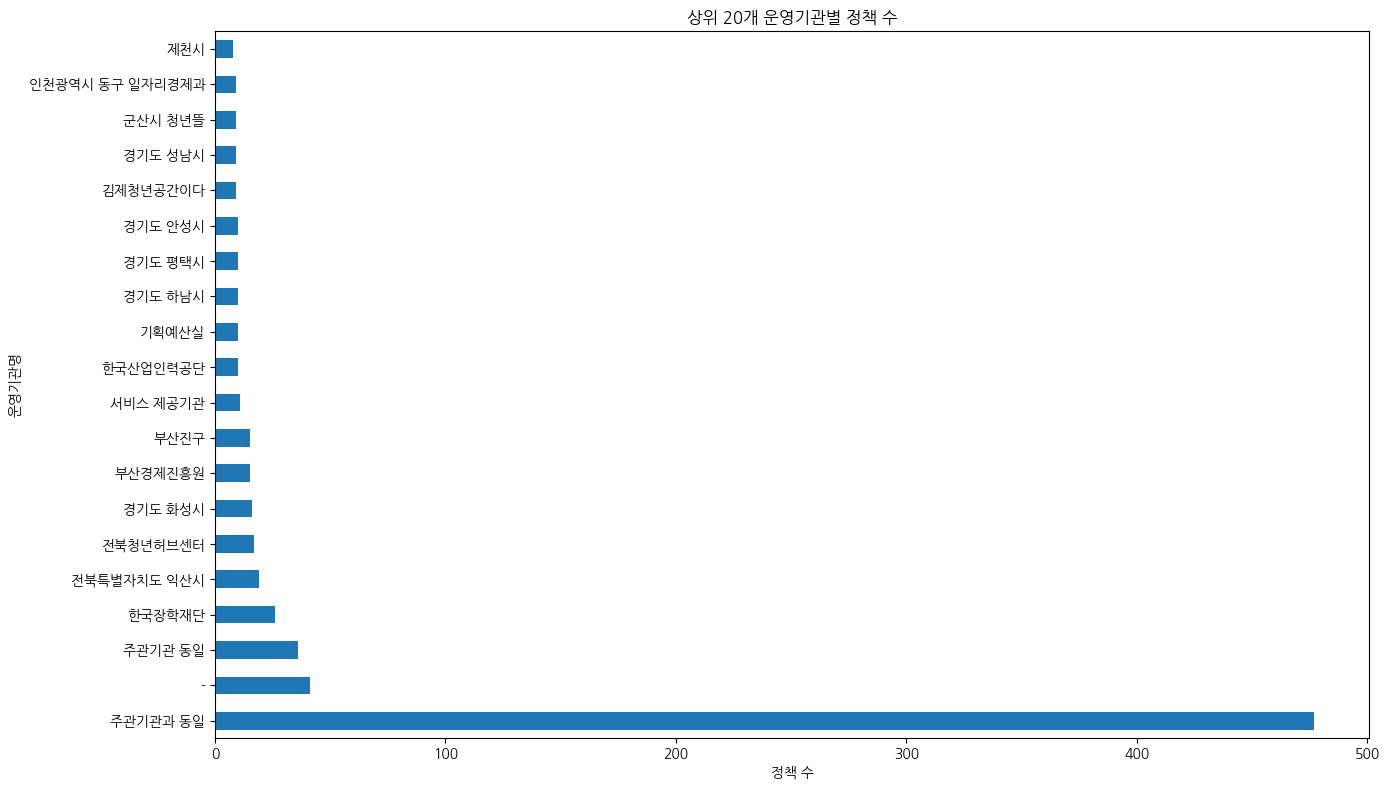

In [40]:
# 상위 20개 운영기관 시각화
plt.figure(figsize=(14, 8))
operInstCdNm_counts.head(20).plot(kind='barh')
plt.title('상위 20개 운영기관별 정책 수')
plt.xlabel('정책 수')
plt.ylabel('운영기관명')
plt.tight_layout()
plt.show()

In [41]:
# 주관기관: 교육부, 운영기관: 한국장학재단

# 지원규모제한여부, 신청기간구분코드

In [45]:
# 지원규모제한여부, 신청기간구분코드
df[['sprtSclLmtYn', 'aplyPrdSeCd']]

,sprtSclLmtYn,aplyPrdSeCd
0,Y,57001
1,N,57002
2,N,57001
3,N,57001
4,N,57001
...,...,...
3453,N,57003
3454,N,57003
3455,N,57003
3456,N,57003


In [61]:
# 지원규모제한여부 카운트
df['sprtSclLmtYn'].value_counts()

sprtSclLmtYn
N    3179
Y     279
Name: count, dtype: int64

In [62]:
df[df['sprtSclLmtYn'] == 'Y'][['plcyExplnCn', 'plcySprtCn', 'plcyAplyMthdCn']]

,plcyExplnCn,plcySprtCn,plcyAplyMthdCn
0,원거리 대학 진학으로 인해 주거 관련 비용 부담이 큰 저소득 대학생을 대상으로 주거...,"□ 지원금액: 월 최대 20만 원\n※ 단, 방학 중(7~8월, 1~2월)에는 지원...",□ 2학기 신청일정: 2025. 5. 23.(금) 9시 ~ 6. 23.(월) 18시...
23,청년들의 취업활동에 따른 구직비용 절감 및 경제적 부담완화를 위해 이력서 사진을 무...,"1:1매칭 포토샵 사진촬영 서비스, 현장 사진인화 제공",광주청년통합플랫폼 회원가입 > 온라인 신청서 작성(증빙서류 제출) > 사진촬영(센터방문)
27,취업 및 이직을 위한 능동적 구직활동을 하는 청년들에게 자격증 응시가 확인 될 경우...,○ 기 간 : '25. 1. ~ 12.\n\n○ 사업대상 : 2025. 1. 1. ...,"울산청년정책플랫폼 누리집을 통한 온라인 신청만 가능, 방문·우편 제출 불가"
29,청년들의 취업활동에 따른 구직비용 절감 및 경제적 부담완화를 위해 무료로 면접 정장...,면접정장대여 무료 서비스[대여기간 3박 4일(공휴일 미포함)]\n\n(남성 대여품목...,광주청년통합플랫폼(https://youth.gwangju.go.kr) 회원가입 → ...
61,"AI 면접체험을 통해 면접을 가상 체험하면서, 면접에 대핸 불안감 해소 및 면접 역...",AI 면접 체험 프로그램 제공,NaN
...,...,...,...
3412,"익산시 (예비)창업자에게 전체 시설비*의 50% 이내 지원(지원한도 10,000천원)","□ 전체 시설비*의 50% 이내 지원(지원한도 10,000천원)\n * 지원범위 ...","□ 방문접수: 익산시 중앙로 22-202, 익산청년시청 4층 청년시청 사무실\n□ ..."
3413,익산시에서 운영하고 있는 복합청년몰 '상상노리터' 입점 희망 청년상인 모집,□ 임대료 지원(입점일로부터 2년간)\n□ 임대기간 : 계약일 ~ 2025. 12....,신청방법 : 이메일 접수(dovetail@korea.kr)
3424,"익산시에서 운영하고 있는 청년몰 ""상상노리터"" 입점을 희망하는 청년 상인 모집","□ 임대료 지원(입점일로부터 2년 간)\n※ 의무 사항 ( 계약기간 유지, 전통시장...",모집 기간 내 이메일 접수(dovetail@korea.kr)
3437,공공분야 일자리 제공,□공공분야 일자리 제공,□ 방문 접수(주민등록상 주소지 읍면동 행정복지센터)


In [60]:
df[df['sprtSclLmtYn'] == 'N'][['plcyExplnCn', 'plcySprtCn', 'plcyAplyMthdCn']]

,plcyExplnCn,plcySprtCn,plcyAplyMthdCn
1,고립·은둔 청년 및 가족돌봄 청(소)년 지원,"1. 청년 돌봄이음 시범사업(제공기관 : 종합사회복지관) : 초기상담, 성장 계획 ...",부산사회서비스원 홈페이지온라인 신청\n○ 고립은둔 청년 지원 신청 : https:/...
2,우울·불안 등 정서적 어려움을 겪는 청년의 마음건강 회복,ㅇ (사업 내용) 2단계 선별검사로 과학적 진단을 통한 맞춤형 상담 지원\n ...,"총 4차(1월, 4월, 6월, 9월)에 걸쳐 참여자를 모집하며, 연도내 중복참여는 ..."
3,"학자금 대출, 주거비, 비정규직 취업 등으로 어려움을 겪고 있는 청년의 자립지원을 ...",□ 본인저축액 : 월 15만원\n□ 매칭지원액 : 본인저축액과 동일한 금액 매월 적...,□ 신청기간 : 2025. 6. 9.(월) ~ 6. 20.(금) 18:00 ※ 신청...
4,청년 금융교육 및 재무상담을 통한 경제적 자립 지원,"무료 재무상담(대면, 비대면) 및 금융교육, 커뮤니티 운영\nㅇ (재무상담) 재무진...",NaN
5,부산 거주 청년 대상 1인 최대 10만원 문화공연 관람권 제공,- 지원금액 : 1인 최대 10만원(1인 1회 예매) ▹공연기획사로 티켓 차액 지급...,□ 신청일시 : 2025. 5. 28.(수) 10:00 ~ \n※ 선착순 선정\n\...
...,...,...,...
3453,학교 밖 청소년이 건강하게 성장할 수 있도록 지원하기 위하여 학교 밖 청소년을 대상...,"(1) 검진항목 : 상담 및 진찰, 신체 계측, 혈액검사, 소변검사, 구강검진 등\...",꿈드림 누리집(www.kdream.or.kr) 검색을 통해 지역별 학교밖청소년지원센...
3454,중소기업에 취업한 청년들에게 저리의 중소기업 취업청년 전월세보증금을 대출,□ 대출금리 : 연 1.5%\n□ 대출한도 : 최대 1억원 이내\n□ 대출기간 : ...,대출조건 확인 ▷ 대출신청 ▷ 자산심사 ▷ 자산심사 결과 정보 송신 ▷ 서류제출 및...
3455,정보통신융합시대에 꼭 필요한 ICT 분야의 정보통신설비 시공 관련 전문 기능인력을 양성,"1. 장학혜택 : 입학생 2년간 등록금 100퍼센트 장학혜택(국가장학금 신청 필수,...",ㅇICT 폴리텍 신입생 수시모집 및 정시모집 공고 확인 후 절차에 맞추어 지원\n①...
3456,"고등학생, 대학생 학업장려금",□ 지원내용 : 최대 40만원 학업장려금 지원\n○ 전입신고 후 6개월 경과 : 1...,"주소지 읍면동 방문, 온라인"


In [59]:
df[df['sprtSclLmtYn'] == 'Y']['plcySprtCn'].iloc[61]

'□ (지원한도 및 지원기간) 지원한도는 1일 상한액 6.6만원, 지원기간은 휴업.휴직을 합하여 연간 180일(무급휴업.휴직은 근로자별 재직기간 중 총 180일)\n\n□ (휴업) 1월간 총 근로시간의 20/100을 초과하여 휴업을 실시하고 휴업수당을 지급한 사업주에게 휴업수당의 2/3(대규모기업 1/2~2/3) 지원\n※ 특별고용지원업종, 고용위기지역은 휴업수당을 지급한 사업주에게 휴업수당의 9/10(대규모기업 2/3~3/4)\n\n□ (휴직) 근로자에게 1월 이상 휴직을 부여하고 휴직수당을 지급한 사업주에게 휴직수당의 2/3(대규모기업 1/2~2/3)를 지원\n\n□ (무급휴업ㆍ휴직) 근로자 평균임금의 50% 범위 내에서 직업안정기관의 장이 결정하여 지원'

신청기간구분코드(aplyPrdSeCd) 빈도:
aplyPrdSeCd
57001    2320
57003     847
57002     291
Name: count, dtype: int64

결측치 개수: 0


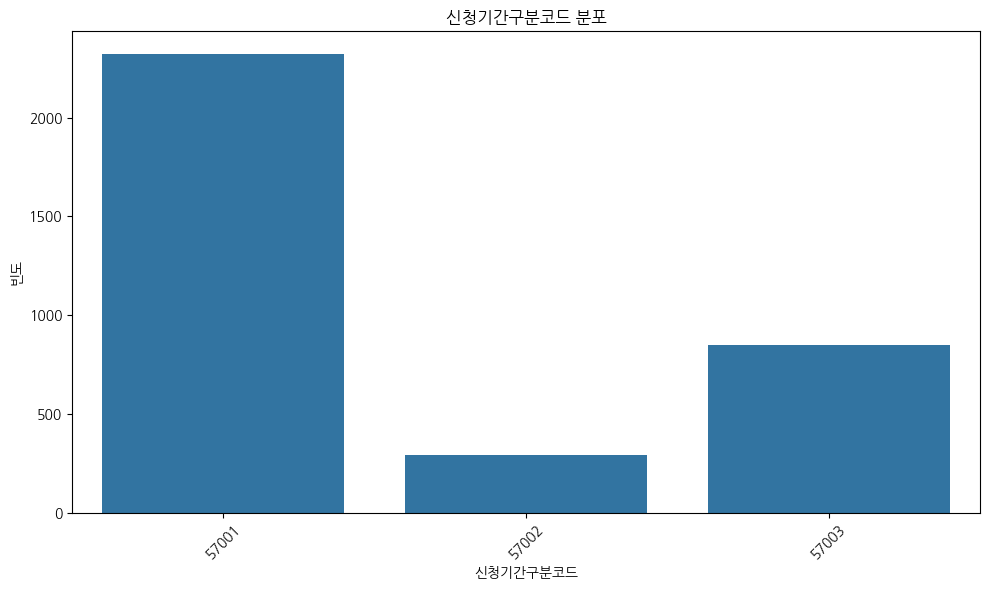

In [46]:
# 신청기간구분코드 빈도 분석
print("신청기간구분코드(aplyPrdSeCd) 빈도:")
aplyPrdSeCd_counts = df['aplyPrdSeCd'].value_counts()
print(aplyPrdSeCd_counts)
print(f"\n결측치 개수: {df['aplyPrdSeCd'].isnull().sum()}")

# 신청기간구분코드 시각화
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='aplyPrdSeCd')
plt.title('신청기간구분코드 분포')
plt.xlabel('신청기간구분코드')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()